In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

import joblib

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median())

In [9]:
df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median())

In [10]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [11]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [13]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [14]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [15]:
df["loan_grade"].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [16]:
df["cb_person_default_on_file"].unique()

array(['Y', 'N'], dtype=object)

In [17]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({'Y': 1, 'N': 0})
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,1,4


In [18]:
grade_mapping = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
df["loan_grade"] = df["loan_grade"].map(grade_mapping)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,4,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,2,1000,11.14,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,3,5500,12.87,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,3,35000,15.23,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,3,35000,14.27,1,0.55,1,4


In [19]:
df = pd.get_dummies(df, columns=["person_home_ownership"], drop_first=True)
df.head()

,person_age,person_income,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,22,59000,123.0,PERSONAL,4,35000,16.02,1,0.59,1,3,False,False,True
1,21,9600,5.0,EDUCATION,2,1000,11.14,0,0.10,0,2,False,True,False
2,25,9600,1.0,MEDICAL,3,5500,12.87,1,0.57,0,3,False,False,False
3,23,65500,4.0,MEDICAL,3,35000,15.23,1,0.53,0,2,False,False,True
4,24,54400,8.0,MEDICAL,3,35000,14.27,1,0.55,1,4,False,False,True


In [20]:
df = pd.get_dummies(df, columns=["loan_intent"], drop_first=True)
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,4,35000,16.02,1,0.59,1,3,False,False,True,False,False,False,True,False
1,21,9600,5.0,2,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25,9600,1.0,3,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23,65500,4.0,3,35000,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
4,24,54400,8.0,3,35000,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False


In [21]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_emp_length            32581 non-null  float64
 3   loan_grade                   32581 non-null  int64  
 4   loan_amnt                    32581 non-null  int64  
 5   loan_int_rate                32581 non-null  float64
 6   loan_status                  32581 non-null  int64  
 7   loan_percent_income          32581 non-null  float64
 8   cb_person_default_on_file    32581 non-null  int64  
 9   cb_person_cred_hist_length   32581 non-null  int64  
 10  person_home_ownership_OTHER  32581 non-null  int64  
 11  person_home_ownership_OWN    32581 non-null  int64  
 12  person_home_ownership_RENT   32581 non-null  int64  
 13  loan_intent_EDUC

In [23]:
#Modeling phase 

In [24]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [25]:
#train-test split 

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 17)
y shape: (32581,)


In [29]:
print(type(X_train_scaled))
print(X_train_scaled.shape)

<class 'numpy.ndarray'>
(26064, 17)


In [30]:
#training logistic regression

In [31]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = log_model.predict(X_test_scaled)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8454810495626822
[[4803  269]
 [ 738  707]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      5072
           1       0.72      0.49      0.58      1445

    accuracy                           0.85      6517
   macro avg       0.80      0.72      0.74      6517
weighted avg       0.84      0.85      0.83      6517



In [34]:
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8608224269481407


In [35]:
#random forest

In [36]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_pred = rf_model.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9307963787018567
[[5022   50]
 [ 401 1044]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.95      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



In [39]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.9371848836955454


In [40]:
import pandas as pd
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False)

loan_percent_income            0.225228
person_income                  0.146184
loan_grade                     0.123438
loan_int_rate                  0.096597
person_home_ownership_RENT     0.084711
loan_amnt                      0.073634
person_emp_length              0.061326
person_age                     0.046158
cb_person_cred_hist_length     0.034450
loan_intent_MEDICAL            0.018575
loan_intent_EDUCATION          0.017064
person_home_ownership_OWN      0.016822
loan_intent_HOMEIMPROVEMENT    0.016281
loan_intent_PERSONAL           0.014422
loan_intent_VENTURE            0.012666
cb_person_default_on_file      0.011381
person_home_ownership_OTHER    0.001064
dtype: float64

In [41]:
#Feature Importance Chart

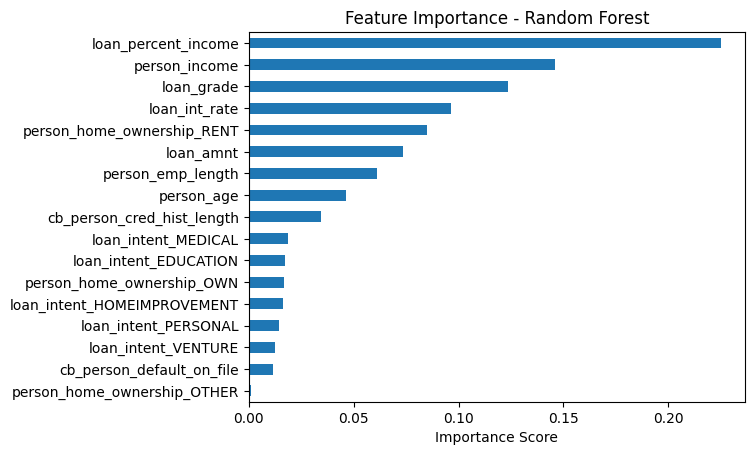

In [42]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [43]:
# Confusion Matrix Visualization

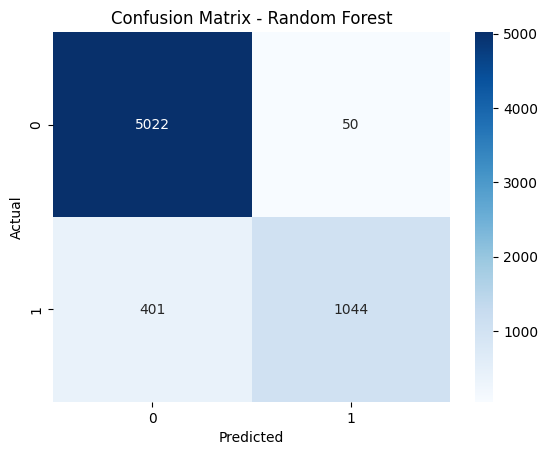

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [45]:
# ROC Curve

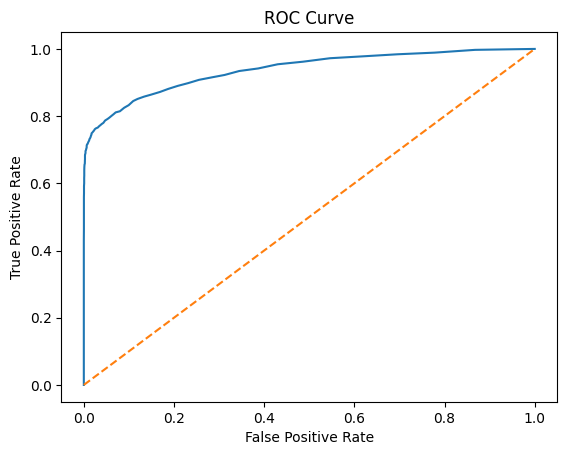

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [47]:
import joblib

joblib.dump(rf_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [48]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [49]:
loaded_model = joblib.load("credit_risk_model.pkl")

test_prediction = loaded_model.predict(X_test)
print("Loaded model accuracy:", accuracy_score(y_test, test_prediction))

Loaded model accuracy: 0.9307963787018567
